In [1]:
import pandas as pd
import pickle
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
import os

print(os.listdir("../../data/processed"))

['final_dataset.csv', 'issues_cleaned.csv', 'test.csv', 'train.csv']


In [3]:
import pandas as pd

df = pd.read_csv("../../data/processed/final_dataset.csv")

In [4]:
df.head()

,summary,description,priority.name,status.name,resolution.name,issuetype.name
0,Update config browser to work with the new syntax,The config browser used Velocity calling the t...,Minor,Closed,Fixed,Improvement
1,XALAN_C 1.9 or current do not build on Fedora ...,Two types of errors:\n1- runConfigure and conf...,Blocker,Resolved,Fixed,Bug
2,"Problem with ADD new post, and DELETE post.","When trying to add new post, I was getting nex...",Critical,Closed,Cannot Reproduce,Bug
3,LogHandler can only work in GlobalConfiguratio...,org.apache.axis.handlers.LogHandler in request...,Major,Open,Unknown,Bug
4,Decoding of service is broken in org.apache.ax...,The following code assumes a lot of things:\n\...,Major,Open,Unknown,Bug


In [5]:
df.columns

Index(['summary', 'description', 'priority.name', 'status.name',
       'resolution.name', 'issuetype.name'],
      dtype='object')

In [6]:
from sklearn.preprocessing import LabelEncoder

# Combine summary and description
df["text"] = (
    df["summary"].fillna("") + " " +
    df["description"].fillna("")
)

# Encode target labels
le = LabelEncoder()
df["target"] = le.fit_transform(df["priority.name"])

In [7]:
print(df[["text", "target"]].head())

                                                text  target
0  Update config browser to work with the new syn...       5
1  XALAN_C 1.9 or current do not build on Fedora ...       0
2  Problem with ADD new post, and DELETE post. Wh...       1
3  LogHandler can only work in GlobalConfiguratio...       4
4  Decoding of service is broken in org.apache.ax...       4


In [8]:
df = df.dropna(subset=["text", "target"])
df["text"] = df["text"].astype(str)

print(df.shape)

(1149323, 8)


In [9]:
X = df["text"]
y = df["target"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
import pickle

# Random Forest
with open("../../models/random_forest.pkl", "rb") as f:
    rf_model = pickle.load(f)

# XGBoost
with open("../../models/xgboost.pkl", "rb") as f:
    xgb_model = pickle.load(f)

# TF-IDF Vectorizer
with open("../../models/tfidf_vectorizer.pkl", "rb") as f:
    tfidf = pickle.load(f)

# Label Encoder
with open("../../models/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print("All models loaded successfully!")

All models loaded successfully!


In [13]:
X_test_tfidf = tfidf.transform(X_test)

print(X_test_tfidf.shape)

(229865, 3000)


In [14]:
rf_pred = rf_model.predict(X_test_tfidf)

In [15]:
print("========== Random Forest ==========")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, rf_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, rf_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, rf_pred, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

========== Random Forest ==========
Accuracy : 0.6501685772083614
Precision: 0.4416124951569992
Recall   : 0.6501685772083614
F1 Score : 0.5132375956208188

Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7295
           1       0.00      0.00      0.00      9903
           2       0.00      0.00      0.00        35
           3       1.00      0.00      0.01      1366
           4       0.65      1.00      0.79    149258
           5       0.00      0.00      0.00     43324
           6       0.71      0.06      0.11      2711
           7       0.00      0.00      0.00       473
           8       0.00      0.00      0.00        55
           9       0.00      0.00      0.00       168
          10       0.12      0.00      0.00      1356
          11       0.80      0.02      0.04      1274
          12       0.00      0.00      0.00        60
          13       0.00      0.00      0.00      6080
          

In [16]:
xgb_pred = xgb_model.predict(X_test_tfidf)

In [17]:
print("========== XGBoost ==========")

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average="weighted", zero_division=0))
print("Recall   :", recall_score(y_test, xgb_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, xgb_pred, average="weighted"))

print("\nClassification Report")
print(classification_report(y_test, xgb_pred, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_pred))

========== XGBoost ==========
Accuracy : 0.6620190111587236
Precision: 0.611811108223574
Recall   : 0.6620190111587236
F1 Score : 0.5414726542619832

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.00      0.01      7295
           1       0.57      0.01      0.02      9903
           2       0.00      0.00      0.00        35
           3       0.54      0.17      0.26      1366
           4       0.67      0.99      0.80    149258
           5       0.54      0.02      0.04     43324
           6       0.66      0.56      0.61      2711
           7       0.64      0.03      0.06       473
           8       1.00      0.02      0.04        55
           9       0.35      0.04      0.06       168
          10       0.47      0.33      0.39      1356
          11       0.53      0.35      0.42      1274
          12       1.00      0.02      0.03        60
          13       0.54      0.01      0.02      6080
          14     

In [18]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average="weighted")
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average="weighted", zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, average="weighted")
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")

In [19]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "F1 Score": [rf_f1, xgb_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.650169,0.441612,0.650169,0.513238
1,XGBoost,0.662019,0.611811,0.662019,0.541473


In [20]:
import torch
import numpy as np

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer
)

from datasets import Dataset

In [21]:
model = BertForSequenceClassification.from_pretrained("../../models/bert_model")

tokenizer = BertTokenizer.from_pretrained("../../models/bert_model")

In [22]:
test_df = pd.DataFrame({
    "text": X_test,
    "labels": y_test
})

In [23]:
test_dataset = Dataset.from_pandas(test_df)

In [24]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [25]:
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/229865 [00:00<?, ? examples/s]

In [26]:
test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [27]:
trainer = Trainer(model=model)

In [28]:
predictions = trainer.predict(test_dataset)

In [29]:
bert_pred = np.argmax(predictions.predictions, axis=1)

bert_true = predictions.label_ids

In [30]:
bert_accuracy = accuracy_score(bert_true, bert_pred)
bert_precision = precision_score(
    bert_true,
    bert_pred,
    average="weighted",
    zero_division=0
)
bert_recall = recall_score(
    bert_true,
    bert_pred,
    average="weighted"
)
bert_f1 = f1_score(
    bert_true,
    bert_pred,
    average="weighted"
)

print("========== BERT ==========")

print("Accuracy :", bert_accuracy)
print("Precision:", bert_precision)
print("Recall   :", bert_recall)
print("F1 Score :", bert_f1)

print("\nClassification Report")
print(classification_report(bert_true, bert_pred, zero_division=0))

print("\nConfusion Matrix")
print(confusion_matrix(bert_true, bert_pred))

========== BERT ==========
Accuracy : 0.6753268222652427
Precision: 0.6232394850090532
Recall   : 0.6753268222652427
F1 Score : 0.624895222412564

Classification Report
              precision    recall  f1-score   support

           0       0.37      0.02      0.04      7295
           1       0.43      0.02      0.05      9903
           2       0.00      0.00      0.00        35
           3       0.50      0.06      0.11      1366
           4       0.72      0.90      0.80    149258
           5       0.42      0.27      0.33     43324
           6       0.59      0.71      0.65      2711
           7       0.00      0.00      0.00       473
           8       0.00      0.00      0.00        55
           9       0.56      0.03      0.06       168
          10       0.43      0.33      0.37      1356
          11       0.44      0.45      0.45      1274
          12       0.00      0.00      0.00        60
          13       0.29      0.14      0.19      6080
          14       0

In [33]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "BERT"],
    "Accuracy": [rf_accuracy, xgb_accuracy, bert_accuracy],
    "Precision": [rf_precision, xgb_precision, bert_precision],
    "Recall": [rf_recall, xgb_recall, bert_recall],
    "F1 Score": [rf_f1, xgb_f1, bert_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.650169,0.441612,0.650169,0.513238
1,XGBoost,0.662019,0.611811,0.662019,0.541473
2,BERT,0.675327,0.623239,0.675327,0.624895


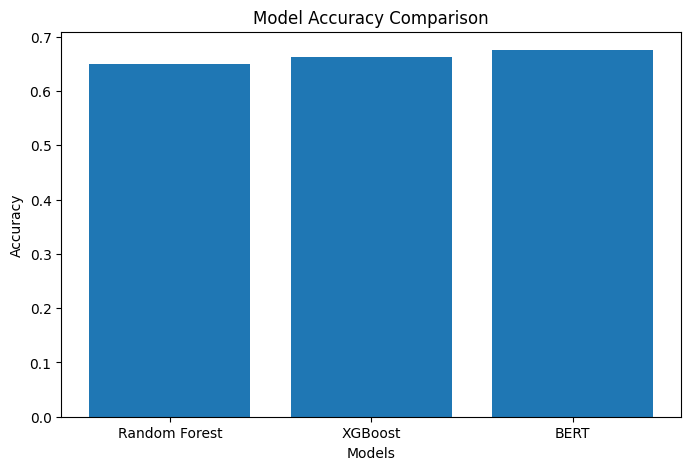

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

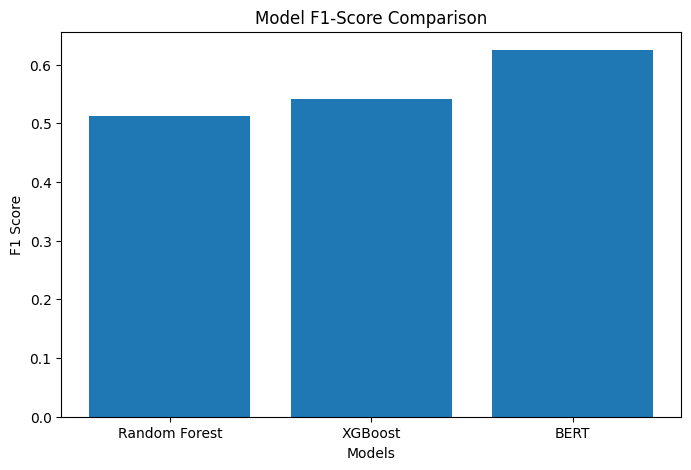

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)

plt.title("Model F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.show()

In [37]:
comparison.to_csv("../../results/model_comparison.csv", index=False)

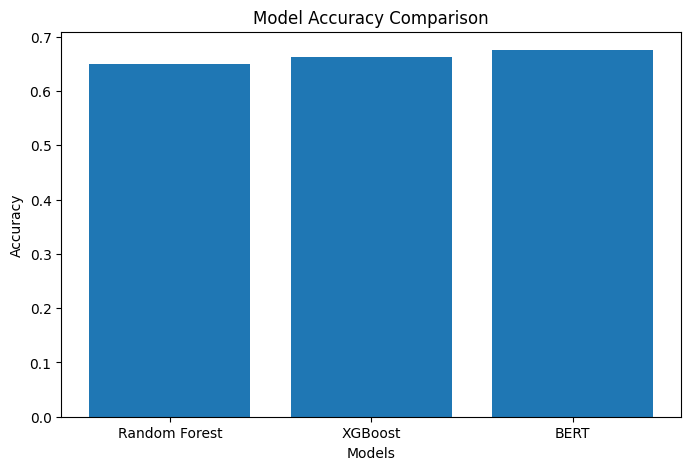

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.savefig("../../results/accuracy_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

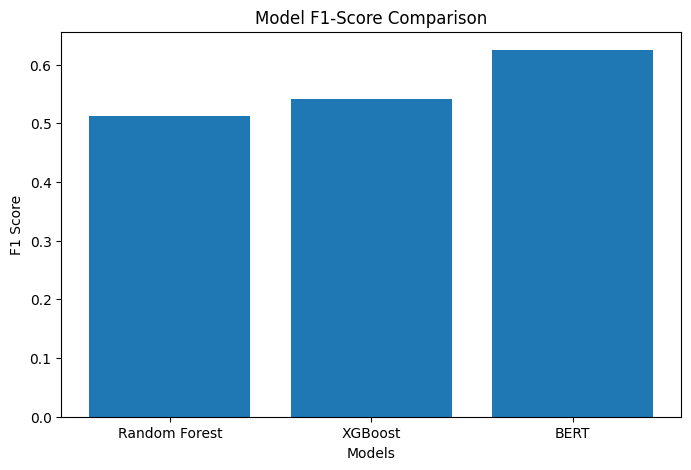

In [44]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["F1 Score"])

plt.title("Model F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.savefig("../../results/f1_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()